[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ushaloy/SAVE-LEWS/blob/main/notebooks/04_thailand_step4_bayesian_two_store.ipynb)

# SAVE-LEWS Thailand — Step 4: Bayesian two-store model (B-TS), calibration (H2), identifiability (H3), transfer (H4)

**Why a two-store model.** Step 3 showed that the 30 cm probe's storm response is carried by a fast, rain-driven store, not by Richards matrix flow; a physics-residual PINN either ignores the physics or loses skill. So the Bayesian step is applied to the physics the sensor actually sees:

rain → **interception store** (capacity c, emptying time τ_c) → effective rain → **fast (preferential-flow) store** F (drainage time τ_F) → probe reading θ_m + (θs − θ_m)·tanh(a·F).

After assimilating the observation at the forecast origin, the forecast has a closed form: Δθ_h = (θs − θ_obs,0)·(t_h − t_0)/(1 − t_0), t = tanh(a·F).

**Bayesian layer.** Posterior over (c, τ_c, a, τ_F) + a Bayesian **discrepancy last layer** (linear head on 5 fixed features per horizon), Student-t likelihood (ν = 30) with separate storm/quiet noise per horizon. Priors: c ~ LogNormal(ln 5 mm, 0.6), τ_c ~ LogNormal(ln 6 h, 1), a ~ LogNormal(ln 0.03 /mm, 1), τ_F ~ LogNormal(ln 8 h, 1). **VI** (full-rank Gaussian, 4 restarts, best ELBO) is the main method; **NUTS** (4 chains × 500) is the reference.

**Protocol.** Same leave-one-storm-out folds and 24 h purge as step 3; training origins every 30 min; evaluation on every held-out storm-time origin. H2 compares the posterior predictive with **cross-conformal** intervals (Mondrian storm/quiet, per horizon, calibrated only on other folds' held-out residuals) around persistence, the M2 PINN and the PG-MLP.

*Selection note:* the likelihood settings (ν = 30, 30-min storm stride) were chosen among 4 variants by looking at held-out folds 1, 4 and 6 — a small selection effect in B-TS's favour.

In [1]:
import os, sys, subprocess, json, warnings
REPO_URL = 'https://github.com/Ushaloy/SAVE-LEWS'   # <-- set this to your GitHub repository before running in Colab
def _repo_root():
    here = os.getcwd()
    for c in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here)), '/content/SAVE-LEWS', os.path.join(here, 'SAVE-LEWS')]:
        if os.path.exists(os.path.join(c, 'thailand', 'data_pipeline.py')):
            return c
    dst = '/content/SAVE-LEWS' if 'google.colab' in sys.modules else os.path.join(here, 'SAVE-LEWS')
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, dst], check=True)
    return dst
ROOT = _repo_root(); os.chdir(os.path.join(ROOT, 'thailand')); sys.path.insert(0, os.getcwd())
for _pkg, _mod in [('numpyro', 'numpyro'), ('optax', 'optax'), ('openpyxl', 'openpyxl')]:
    try: __import__(_mod)
    except ImportError: subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _pkg], check=True)
DATA = '../data/thailand'
print('repository:', ROOT, '| working folder:', os.getcwd())
try:
    import numpyro
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'jax[cpu]', 'numpyro'], check=True)
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.width', 200)
RERUN_CHECK = True     # refit one fold with VI (~20 s) and compare with the stored result

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repository: /content/SAVE-LEWS | working folder: /content/SAVE-LEWS/thailand


## 1. Modules (the full LOSO run is `run_bts.py`, ~25 min on 2 cores)

The modules are the `.py` files in `thailand/` of this repository; they are imported below.

In [2]:
import importlib, bts, h2_compare, train_loso
from train_loso import load_device, storm_catalogue, make_window, loso_windows
from bts import *
from h2_compare import table, pooled, recalibrate, load_point
bts.set_nu(30.0)
g108 = load_device(f'{DATA}/pinn_108_new.csv').loc['2025-11-01 10:40':]; S108 = storm_catalogue(g108)
if not os.path.exists('bts_out/res4_0.json'):
    print('stored results missing: run  python run_bts.py 0..6 all  and  python conf_preds.py  first')

## 2. Verification: refit fold 1 with VI and compare with the stored run

In [3]:
if RERUN_CHECK:
    D = pack(loso_windows(g108, S108, 1), stride=6, storm_stride=6); Phi = features(D, 0.55, 0.05)
    best = None
    for seed in range(4):
        post, losses = fit_vi(D, Phi, 0.55, 0.05, seed=seed)
        L = losses[-200:].mean()
        if best is None or L < best[1]: best = (post, L)
    Dh = pack([make_window(g108, S108.iloc[1])]); _, yy = predictive(best[0], Dh, 0.55, 0.05)
    m, _ = interval_metrics(yy, Dh)
    stored = json.load(open('bts_out/res4_1.json'))['held_vi_oracle']
    print(pd.DataFrame({h: {'coverage now': m[f'storm_{h}']['coverage'], 'coverage stored': stored[f'storm_{h}']['coverage'],
                            'width now': m[f'storm_{h}']['width'], 'width stored': stored[f'storm_{h}']['width']} for h in (30, 60, 120)}).round(4))

                    30      60      120
coverage now     0.9471  0.9235  0.8647
coverage stored  0.9471  0.9235  0.8647
width now        0.0185  0.0278  0.0362
width stored     0.0185  0.0278  0.0362


## 3. Inference diagnostics (NUTS reference vs VI)

In [4]:
rows = []
for f in list(range(7)) + ['all']:
    r = json.load(open(f'bts_out/res4_{f}.json')); d = r['nuts']['diag']
    rows.append({'fold': f, 'max R-hat': max(v['r_hat'] for k, v in d.items() if k != 'divergences'),
                 'min n_eff': min(v['n_eff'] for k, v in d.items() if k != 'divergences'), 'divergences': d['divergences'],
                 'a  VI median': r['vi']['post']['a']['q50'], 'a  NUTS median': r['nuts']['post']['a']['q50'],
                 'τ_F VI median': r['vi']['post']['tau_F']['q50'], 'τ_F NUTS median': r['nuts']['post']['tau_F']['q50'],
                 'τ_F NUTS chain medians': [round(x, 1) for x in r['nuts']['chain_medians']['tau_F']]})
pd.DataFrame(rows).round(4)

,fold,max R-hat,min n_eff,divergences,a VI median,a NUTS median,τ_F VI median,τ_F NUTS median,τ_F NUTS chain medians
0,0,1.0032,1184.2647,0,0.0395,0.0393,8.5246,8.6740,"[8.7, 8.7, 8.7, 8.7]"
1,1,1.0032,872.7468,8,0.0183,0.0183,6.1932,6.0776,"[6.0, 6.1, 6.1, 6.1]"
2,2,4.8854,2.0807,0,0.0504,0.0725,554.9113,0.7080,"[0.7, 0.7, 0.7, 705.0]"
3,3,1.0062,671.7335,58,0.0162,0.0162,8.3991,8.1505,"[8.2, 8.1, 8.1, 8.2]"
4,4,1.0062,671.7335,58,0.0162,0.0162,8.3991,8.1505,"[8.2, 8.1, 8.1, 8.2]"
5,5,1.0075,1251.9097,1,0.0155,0.0153,8.9871,9.0960,"[9.0, 9.1, 9.1, 9.1]"
6,6,6.6765,2.0439,2,0.0115,0.0120,11.8679,12.0960,"[11.6, 11.6, 326.5, 11.5]"
7,all,1.0068,522.3119,3,0.0185,0.0181,7.8727,7.9066,"[7.9, 7.9, 7.9, 7.9]"


Folds 2 and 6 are **multimodal** (R-hat > 1.3): chains disagree on τ_F (a fast store vs a near-permanent one); VI silently picks one mode. Elsewhere VI and NUTS agree closely. Folds 3 and 4 are identical because the purge leaves them the same training storms.

## 4. H2 — interval calibration on held-out storms (storm-time, oracle rain)

In [5]:
for drop, lab in [((), 'all 7 storms'), ((2,), 'storm 2 excluded from evaluation')]:
    T = pd.concat({k: pooled(v, drop) for k, v in table('oracle').items()}, axis=0)
    print(f'--- {lab} ---'); display(T.round(4).unstack('h'))

--- all 7 storms ---

coverage                 mean width                 interval score                   skill                
h                               30      60      120        30      60      120            30      60      120     30      60      120
B-TS vi (raw)                0.6162  0.6527  0.6109     0.0171  0.0261  0.0338         0.1747  0.1701  0.1960 -5.3381 -2.2871 -1.2855
B-TS vi + conformal          0.7193  0.8407  0.8672     0.0795  0.0893  0.1033         0.2083  0.1765  0.1733 -5.3381 -2.2871 -1.2855
B-TS nuts (raw)              0.8567  0.8233  0.8139     0.0254  0.0353  0.0476         0.0474  0.0660  0.0963 -0.3023 -1.4773 -2.1727
B-TS nuts + conformal        0.8732  0.8820  0.8914     0.0321  0.0548  0.0786         0.0522  0.0739  0.1111 -0.3023 -1.4773 -2.1727
B-TS vi_nodisc (raw)         0.5918  0.5500  0.6197     0.0185  0.0290  0.0398         0.1867  0.1752  0.1775 -5.9856 -2.7725 -1.5592
B-TS vi_nodisc + conformal   0.6664  0.8120  0.8685     0.0688  0.0781  0.0871         0.2168  0.1646  0.1395 -5.9856 -2.7725 -1.5592
persistence + conformal      0.9055  0.9007  0.8975     0.0166  0.0380  0.0533         0.0448  0.0770  0.0902  0.0000  0.0000  0.0000
M2 + conformal               0.8388  0.8987  0.8982     0.0233  0.0338  0.0445         0.0435  0.0469  0.0688  0.1961  0.3967  0.4049
PGMLP + conformal            0.9037  0.9142  0.8942     0.0262  0.0304  0.0372         0.0400  0.0487  0.0497  0.1293  0.4186  0.5794

--- storm 2 excluded from evaluation ---


coverage                 mean width                 interval score                   skill                
h                               30      60      120        30      60      120            30      60      120     30      60      120
B-TS vi (raw)                0.8549  0.7848  0.7448     0.0176  0.0270  0.0363         0.0437  0.0689  0.1052  0.3925  0.3795  0.2422
B-TS vi + conformal          1.0000  1.0000  1.0000     0.1101  0.1143  0.1282         0.1101  0.1143  0.1282  0.3925  0.3795  0.2422
B-TS nuts (raw)              0.8498  0.7807  0.7448     0.0173  0.0266  0.0369         0.0438  0.0695  0.1036  0.3964  0.3818  0.2519
B-TS nuts + conformal        0.8589  0.8213  0.8388     0.0216  0.0374  0.0527         0.0453  0.0665  0.1012  0.3964  0.3818  0.2519
B-TS vi_nodisc (raw)         0.8889  0.8102  0.7469     0.0181  0.0280  0.0373         0.0436  0.0650  0.0969  0.3802  0.3804  0.2868
B-TS vi_nodisc + conformal   1.0000  0.9980  0.9897     0.0938  0.0952  0.0938         0.0938  0.0953  0.0940  0.3802  0.3804  0.2868
persistence + conformal      0.8709  0.8487  0.8430     0.0149  0.0289  0.0491         0.0565  0.0883  0.1057  0.0000  0.0000  0.0000
M2 + conformal               0.9219  0.8822  0.8678     0.0265  0.0333  0.0426         0.0398  0.0496  0.0779  0.5141  0.5761  0.5177
PGMLP + conformal            0.8987  0.8699  0.9026     0.0261  0.0275  0.0374         0.0465  0.0560  0.0551  0.3230  0.5368  0.7154

Sensitivity: cross-conformal is only as good as its worst calibration fold — storm 2's huge residuals inflate every other fold's intervals. Below, storm 2 is also **removed from the calibration pool** (a gated-regime scenario, e.g. applying the Se ≥ 0.9 gate; not a fair headline number).

In [6]:
T = pd.concat({k: pooled(v, (2,)) for k, v in table('oracle', (2,)).items()}, axis=0)
T.round(4).unstack('h')

coverage                 mean width                 interval score                   skill                
h                               30      60      120        30      60      120            30      60      120     30      60      120
B-TS vi (raw)                0.8549  0.7848  0.7448     0.0176  0.0270  0.0363         0.0437  0.0689  0.1052  0.3925  0.3795  0.2422
B-TS vi + conformal          0.8338  0.8528  0.8585     0.0210  0.0438  0.0658         0.0479  0.0652  0.1042  0.3925  0.3795  0.2422
B-TS nuts (raw)              0.8498  0.7807  0.7448     0.0173  0.0266  0.0369         0.0438  0.0695  0.1036  0.3964  0.3818  0.2519
B-TS nuts + conformal        0.8308  0.8457  0.8543     0.0209  0.0432  0.0660         0.0479  0.0655  0.1044  0.3964  0.3818  0.2519
B-TS vi_nodisc (raw)         0.8889  0.8102  0.7469     0.0181  0.0280  0.0373         0.0436  0.0650  0.0969  0.3802  0.3804  0.2868
B-TS vi_nodisc + conformal   0.8519  0.8660  0.8605     0.0190  0.0400  0.0619         0.0462  0.0619  0.0932  0.3802  0.3804  0.2868
persistence + conformal      0.9049  0.8954  0.9008     0.0205  0.0546  0.0603         0.0564  0.0805  0.1036  0.0000  0.0000  0.0000
M2 + conformal               0.8749  0.8792  0.8864     0.0170  0.0336  0.0471         0.0395  0.0507  0.0808  0.5141  0.5761  0.5177
PGMLP + conformal            0.8954  0.8964  0.9037     0.0257  0.0347  0.0373         0.0480  0.0575  0.0555  0.3230  0.5368  0.7154

### Past data only (no rain nowcast), storm 2 excluded

In [7]:
T = pd.concat({k: pooled(v, (2,)) for k, v in table('past', (2,)).items()}, axis=0)
T.round(4).unstack('h')

coverage                 mean width                 interval score                   skill                
h                               30      60      120        30      60      120            30      60      120     30      60      120
B-TS vi (raw)                0.8388  0.7553  0.6684     0.0176  0.0270  0.0362         0.0588  0.1008  0.1603 -0.0775 -0.1531 -0.3840
B-TS vi + conformal          0.8368  0.8883  0.8430     0.0247  0.0550  0.0807         0.0619  0.0828  0.1383 -0.0775 -0.1531 -0.3840
B-TS nuts (raw)              0.8318  0.7523  0.6746     0.0173  0.0266  0.0369         0.0588  0.1013  0.1577 -0.0733 -0.1484 -0.3687
B-TS nuts + conformal        0.8378  0.8812  0.8440     0.0242  0.0549  0.0817         0.0615  0.0833  0.1392 -0.0733 -0.1484 -0.3687
B-TS vi_nodisc (raw)         0.8669  0.7807  0.6808     0.0181  0.0279  0.0373         0.0572  0.0943  0.1448 -0.0659 -0.1220 -0.2910
B-TS vi_nodisc + conformal   0.8649  0.8985  0.8709     0.0218  0.0547  0.0715         0.0588  0.0814  0.1196 -0.0659 -0.1220 -0.2910
persistence + conformal      0.9049  0.8954  0.9008     0.0205  0.0546  0.0603         0.0564  0.0805  0.1036  0.0000  0.0000  0.0000
M2 + conformal               0.8709  0.8964  0.8895     0.0214  0.0559  0.0704         0.0587  0.0820  0.1160 -0.0665 -0.1073 -0.2347
PGMLP + conformal            0.8954  0.8942  0.8970     0.0265  0.0494  0.0702         0.0540  0.0787  0.1114  0.0258  0.0152 -0.0764

## 5. H3 — what does one probe + a rain gauge identify?

In [8]:
rows = []
for f in range(7):
    p = json.load(open(f'bts_out/res4_{f}.json'))['nuts']['post']
    rows.append({'fold': f, **{f'{k} [q05, q50, q95]': f"{p[k]['q05']:.3g}, {p[k]['q50']:.3g}, {p[k]['q95']:.3g}" for k in ['c', 'tau_c', 'a', 'tau_F']}})
display(pd.DataFrame(rows))
rows = []
for k, (m, s) in PRIOR.items():
    sd = [json.load(open(f'bts_out/res4_{f}.json'))['nuts']['post'][k]['sd_log'] for f in range(7)]
    med = [json.load(open(f'bts_out/res4_{f}.json'))['nuts']['post'][k]['q50'] for f in range(7)]
    rows.append({'parameter': k, 'prior sd(log)': s, 'posterior sd(log), median over folds': np.median(sd),
                 'sd(log) of fold medians': np.std(np.log(med)), 'ratio between-fold / within-fold': np.std(np.log(med)) / np.median(sd)})
pd.DataFrame(rows).round(3)

,fold,"c [q05, q50, q95]","tau_c [q05, q50, q95]","a [q05, q50, q95]","tau_F [q05, q50, q95]"
0,0,"1.02, 1.17, 1.33","7.1, 10.1, 14","0.038, 0.0393, 0.0408","8.3, 8.67, 9.07"
1,1,"1.22, 1.58, 2.09","14.6, 31.9, 85.2","0.0164, 0.0183, 0.0202","4.89, 6.08, 7.68"
2,2,"2.54, 3.81, 4.02","14.7, 20.4, 28.9","0.05, 0.0725, 0.0796","0.629, 0.708, 897"
3,3,"1.55, 2.09, 2.77","21.4, 39.4, 91.2","0.0144, 0.0162, 0.0183","6.23, 8.15, 10.1"
4,4,"1.55, 2.09, 2.77","21.4, 39.4, 91.2","0.0144, 0.0162, 0.0183","6.23, 8.15, 10.1"
5,5,"2.16, 2.84, 3.42","42.3, 95.7, 232","0.0137, 0.0153, 0.0172","7.09, 9.1, 11"
6,6,"2.49, 3.32, 3.94","17.8, 53.2, 156","0.0103, 0.012, 0.0135","9.23, 12.1, 366"


,parameter,prior sd(log),"posterior sd(log), median over folds",sd(log) of fold medians,ratio between-fold / within-fold
0,c,0.6,0.166,0.386,2.325
1,tau_c,1.0,0.447,0.660,1.476
2,a,1.0,0.073,0.596,8.120
3,tau_F,1.0,0.144,0.891,6.201


The data contract every parameter strongly within a fold, but the fold-to-fold spread of the posterior medians is **1.5–8× larger** than the posterior width: the posterior treats the soil as stationary, the storms say it is not. The interception capacity c (1.2–3.8 mm) does not recover the observed ~5 mm threshold.

## 6. H4 — zero-shot Dev108 → Dev107 (posterior from all 7 Dev108 storms; θr/θs anchored to Dev107)

In [9]:
r = json.load(open('bts_out/res4_all.json')); S107 = storm_catalogue(load_device(f'{DATA}/107_pinn.csv'))
rows = []
for m in ['vi', 'nuts']:
    for s in range(4):
        for h in (30, 60, 120):
            x = r[f'd107s{s}_{m}_oracle'][f'storm_{h}']
            rows.append({'method': m, 'storm': str(S107.start[s].date()), 'h': h, 'coverage': x['coverage'], 'skill': 1 - x['mse'] / x['msep']})
pd.DataFrame(rows).pivot_table(index=['method', 'storm'], columns='h', values=['coverage', 'skill']).round(2)

coverage             skill            
h                      30    60    120   30    60    120
method storm                                            
nuts   2025-11-10     0.92  0.91  0.84  0.23  0.33  0.41
       2025-11-19     0.94  0.98  0.98  0.48  0.53  0.42
       2025-12-25     0.81  0.79  0.56 -0.24 -0.15 -0.08
       2025-12-28     0.93  0.91  0.87  0.37  0.45  0.51
vi     2025-11-10     0.92  0.91  0.84  0.24  0.34  0.42
       2025-11-19     0.94  0.98  0.98  0.49  0.53  0.41
       2025-12-25     0.81  0.79  0.55 -0.26 -0.16 -0.08
       2025-12-28     0.93  0.91  0.87  0.38  0.46  0.52

For comparison (step 3, 60 min, oracle): PG-MLP 0.44–0.66 on three storms and −4.2 to −5.9 on 25 Dec; M2 0.57 / −0.35 / −0.60 / 0.71.

## 7. Figures

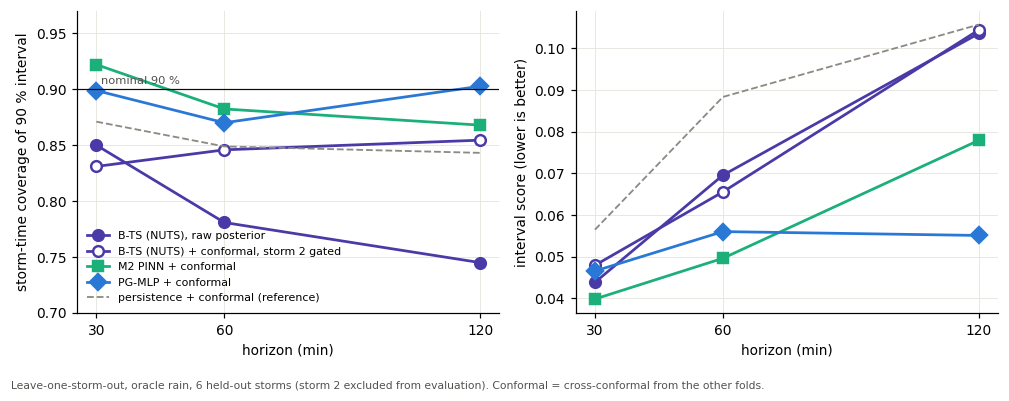

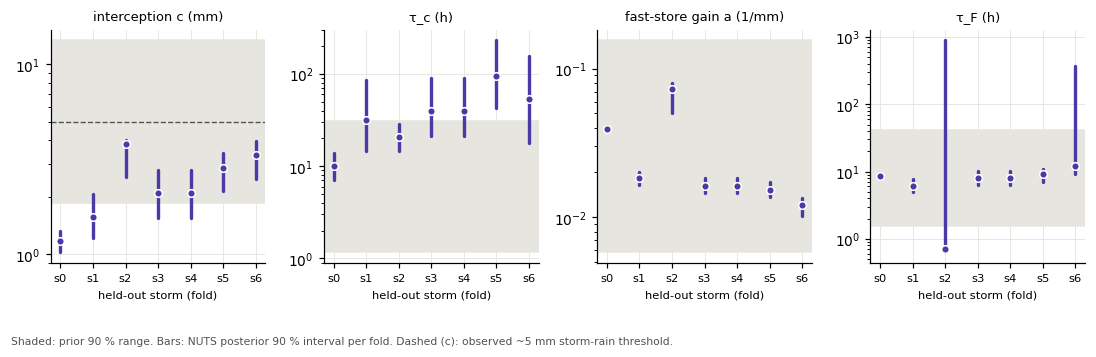

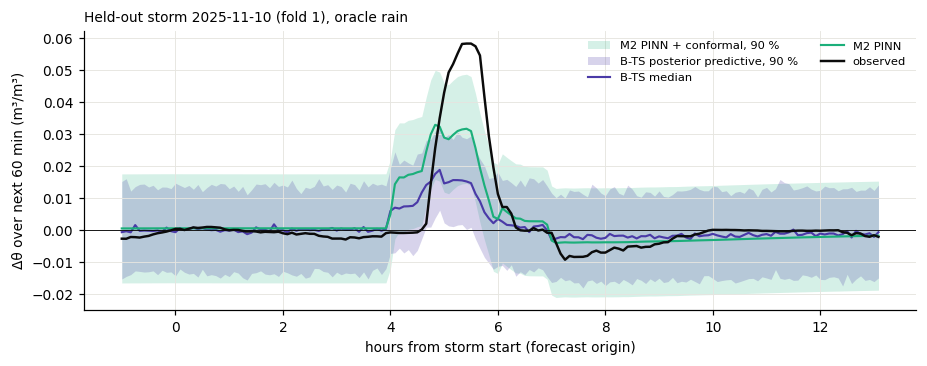

In [10]:
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.color': '#e6e5e0',
                     'grid.linewidth': 0.6, 'font.size': 9, 'figure.dpi': 110})
os.makedirs('figs', exist_ok=True)
C_PG, C_M2, C_BTS, C_REF = '#2a78d6', '#1baf7a', '#4a3aa7', '#8c8a83'
HS = [30, 60, 120]

# Fig 11: H2 — coverage and interval score, oracle, 6 regular storms (storm 2 excluded from evaluation)
T = {k: pooled(v, (2,)) for k, v in table('oracle').items()}
TG = {k: pooled(v, (2,)) for k, v in table('oracle', (2,)).items()}
series = [('B-TS (NUTS), raw posterior', T['B-TS nuts (raw)'], C_BTS, 'o', True),
          ('B-TS (NUTS) + conformal, storm 2 gated', TG['B-TS nuts + conformal'], C_BTS, 'o', False),
          ('M2 PINN + conformal', T['M2 + conformal'], C_M2, 's', True),
          ('PG-MLP + conformal', T['PGMLP + conformal'], C_PG, 'D', True)]
fig, ax = plt.subplots(1, 2, figsize=(9.2, 3.6))
for lab, d, col, mk, filled in series:
    kw = dict(color=col, lw=1.8, marker=mk, ms=7, label=lab, mfc=col if filled else 'white', mec=col, mew=1.6)
    ax[0].plot(HS, d['coverage'].values, **kw); ax[1].plot(HS, d['interval score'].values, **kw)
pers = T['persistence + conformal']
ax[0].plot(HS, pers['coverage'].values, color=C_REF, lw=1.2, ls='--', label='persistence + conformal (reference)')
ax[1].plot(HS, pers['interval score'].values, color=C_REF, lw=1.2, ls='--')
ax[0].axhline(0.9, color='#0b0b0b', lw=0.8); ax[0].text(31, 0.905, 'nominal 90 %', fontsize=7.5, color='#52514e')
ax[0].set_ylim(0.7, 0.97); ax[0].set_ylabel('storm-time coverage of 90 % interval')
ax[1].set_ylabel('interval score (lower is better)')
for a in ax: a.set_xticks(HS); a.set_xlabel('horizon (min)')
ax[0].legend(frameon=False, fontsize=7.2, loc='lower left')
fig.text(0.01, 0.01, 'Leave-one-storm-out, oracle rain, 6 held-out storms (storm 2 excluded from evaluation). Conformal = cross-conformal from the other folds.',
         fontsize=7, color='#52514e')
fig.tight_layout(); fig.subplots_adjust(bottom=0.2); fig.savefig('figs/fig11_h2_calibration.png', dpi=300); plt.show()

# Fig 12: H3 — per-fold posterior 90 % intervals vs prior
fig, ax = plt.subplots(1, 4, figsize=(10, 3.2))
labs = {'c': 'interception c (mm)', 'tau_c': 'τ_c (h)', 'a': 'fast-store gain a (1/mm)', 'tau_F': 'τ_F (h)'}
for j, k in enumerate(['c', 'tau_c', 'a', 'tau_F']):
    m, s = PRIOR[k]
    ax[j].axhspan(np.exp(m - 1.645 * s), np.exp(m + 1.645 * s), color='#e6e5e0', zorder=0)
    for f in range(7):
        p = json.load(open(f'bts_out/res4_{f}.json'))['nuts']['post'][k]
        ax[j].plot([f, f], [p['q05'], p['q95']], color=C_BTS, lw=2.2, solid_capstyle='round')
        ax[j].plot(f, p['q50'], 'o', color=C_BTS, ms=5, mec='white')
    ax[j].set_yscale('log'); ax[j].set_xticks(range(7)); ax[j].set_xticklabels([f's{f}' for f in range(7)], fontsize=7.5)
    ax[j].set_title(labs[k], fontsize=8.5); ax[j].set_xlabel('held-out storm (fold)', fontsize=7.5)
ax[0].axhline(5.0, color='#52514e', lw=0.9, ls='--')
fig.text(0.01, 0.01, 'Shaded: prior 90 % range. Bars: NUTS posterior 90 % interval per fold. Dashed (c): observed ~5 mm storm-rain threshold.',
         fontsize=7, color='#52514e')
fig.tight_layout(); fig.subplots_adjust(bottom=0.24); fig.savefig('figs/fig12_h3_posteriors.png', dpi=300); plt.show()

# Fig 13: example held-out storm, 60-min forecasts with 90 % bands
f = 1; j = 1
z = np.load(f'bts_out/{f}_held_nuts_oracle.npz'); cz = np.load(f'conf_out/held_{f}.npz')
Rm2 = recalibrate(load_point('M2', 'oracle'), 'point')[f]
st = z['storm'] & z['ym'][:, j]
wf = make_window(g108, S108.iloc[f]); t_idx = wf['t'][pack([wf])['ki']]
t_idx = (t_idx - S108.start[f]).total_seconds() / 3600.0      # hours from storm start
fig, ax = plt.subplots(figsize=(8.5, 3.4))
tt = t_idx[st]
ax.fill_between(tt, Rm2['lo'][st, j], Rm2['hi'][st, j], color=C_M2, alpha=0.18, lw=0, label='M2 PINN + conformal, 90 %')
ax.fill_between(tt, z['lo'][st, j], z['hi'][st, j], color=C_BTS, alpha=0.22, lw=0, label='B-TS posterior predictive, 90 %')
ax.plot(tt, z['med'][st, j], color=C_BTS, lw=1.4, label='B-TS median')
ax.plot(tt, Rm2['med'][st, j], color=C_M2, lw=1.4, label='M2 PINN')
ax.plot(tt, z['y'][st, j], color='#0b0b0b', lw=1.6, label='observed')
ax.axhline(0, color='#0b0b0b', lw=0.6)
ax.set_ylabel('Δθ over next 60 min (m³/m³)'); ax.set_xlabel('hours from storm start (forecast origin)'); ax.legend(frameon=False, fontsize=7.5, ncol=2, loc='upper right')
ax.set_title(f'Held-out storm {S108.start[f].date()} (fold {f}), oracle rain', fontsize=9, loc='left')
fig.tight_layout(); fig.savefig('figs/fig13_example_storm.png', dpi=300); plt.show()
